## CLUSTERING

##### IN THIS DOCUMENT I WILL DOCUMENT VARIOUS CLUSTERING ALGORITHM

In [220]:
import numpy as np
import pandas as pd
from sklearn.cluster import DBSCAN
from sklearn.cluster import KMeans
from sklearn.cluster import AffinityPropagation
from sklearn import metrics
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from itertools import cycle

In [184]:
plt.rcParams["figure.figsize"] = (10,7)
variance = .45

#### LETS CREATE SOME RANDOM BLOBS

In [259]:
centers = np.array([[1, 1], [-1, -1], [1, -1],[-1, 1]])
x, labels_true = make_blobs(n_samples=1000, centers=centers, cluster_std=variance, random_state=25)
df = pd.DataFrame(x)
df["labels"] = labels_true
print(list(centers))
df.sample(3)

[array([1, 1]), array([-1, -1]), array([ 1, -1]), array([-1,  1])]


,0,1,labels
693,-0.893204,-1.138321,1
352,-1.044490,0.763683,3
741,-1.214696,0.378342,3


#### LETS PLOT THE ORIGINAL BLOB

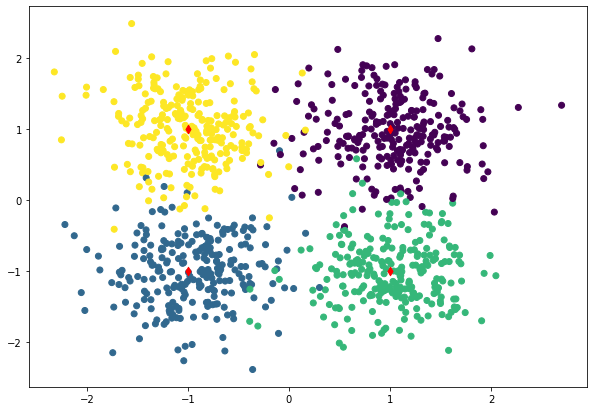

In [186]:
plt.scatter(df.loc[:,0],df.loc[:,1],c=df.labels)
plt.scatter(centers[:,0],centers[:,1], color="red",marker="d")

## METRICS

In [187]:
def clustering_metrics(labels_true, labels, n_clusters=None, n_noise=None):
    print("Estimated number of clusters: %d" % n_clusters)
    print("Estimated number of noise points: %d" % n_noise)
    print("Homogeneity: %0.3f" % metrics.homogeneity_score(labels_true, labels))
    print("Completeness: %0.3f" % metrics.completeness_score(labels_true, labels))
    print("V-measure: %0.3f" % metrics.v_measure_score(labels_true, labels))
    print("Adjusted Rand Index: %0.3f" % metrics.adjusted_rand_score(labels_true, labels))
    print("Adjusted Mutual Information: %0.3f" % metrics.adjusted_mutual_info_score(labels_true, labels))
    print("Silhouette Coefficient: %0.3f" % metrics.silhouette_score(X, labels))

# K-Means

In [188]:
kmeans = KMeans(n_clusters=4, n_init=3, init="k-means++", random_state=50).fit(x)
df["kmeans"] = kmeans.labels_
n_clusters = kmeans.n_clusters
n_noise = list(labels).count(-1)
print(kmeans.cluster_centers_)

[[-0.99125555  1.02721601]
 [ 1.02683852  0.98035514]
 [-0.94867331 -1.00278661]
 [ 1.02980731 -1.01273898]]


### LETS SEE IF THERE IS ANY MOVEMENT FROM ORIGINAL BLOB TO OTHER CLUSTERS

- Can you guess what will happen to movement if variance go up or down

In [189]:
pd.concat([df.labels.value_counts(),df.kmeans.value_counts()], axis=1)

,labels,kmeans
1,250,249
0,250,250
3,250,248
2,250,253


### K-Means Metrics

In [190]:
clustering_metrics(labels_true,kmeans.labels_,n_clusters=n_clusters,n_noise=n_noise)

Estimated number of clusters: 4
Estimated number of noise points: 0
Homogeneity: 0.878
Completeness: 0.878
V-measure: 0.878
Adjusted Rand Index: 0.914
Adjusted Mutual Information: 0.878
Silhouette Coefficient: 0.599


### K-Means Plot

- Notice how the centers have shifted.
- There will be less shift in center if data has less variance

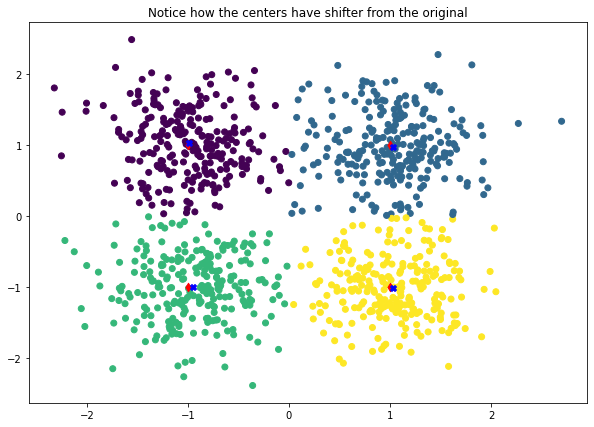

In [191]:
plt.title("Notice how the centers have shifter from the original")
plt.scatter(df.loc[:,0],df.loc[:,1],c=df.kmeans)
plt.scatter(centers[:,0],centers[:,1], color="red",marker="d")
plt.scatter(kmeans.cluster_centers_[:,0],kmeans.cluster_centers_[:,1], color="blue",marker="X")

## DBSCAN

- Works best when variance is low especially if metric is done KNearestNeighbors
- Try the process again with lower variance

In [196]:
db = DBSCAN(eps=.2, min_samples=10).fit( df.loc[:,:1] )
df["dbscan"] = db.labels_
n_clusters = len(set(db.labels_)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)
db_centroids = df.groupby(by="dbscan")[[0,1]].mean()

core_samples_mask = np.zeros_like(db.labels_, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True
db_centroids

,0,1
dbscan,,
-1,0.013245,0.012722
0,-0.893695,-0.985611
1,1.059333,1.024461
2,-0.966914,1.029135
3,1.086041,0.031482
4,1.041469,-1.037015
5,-1.424423,0.338493
6,-1.651902,-1.107901


### LETS SEE IF THERE IS ANY MOVEMENT FROM ORIGINAL BLOB TO OTHER CLUSTERS

- Can you guess what will happen to movement if variance go up or down
- With high variance it looks like most will go to noise

In [197]:
pd.concat([df.labels.value_counts(),df.dbscan.value_counts()], axis=1)

,labels,dbscan
1,250.0,186
0,250.0,197
3,250.0,17
2,250.0,198
4,NaN,195
-1,NaN,187
5,NaN,12
6,NaN,8


### DBSCAN Metrics

In [198]:
clustering_metrics(labels_true,db.labels_,n_clusters=n_clusters,n_noise=n_noise)

Estimated number of clusters: 8
Estimated number of noise points: 0
Homogeneity: 0.784
Completeness: 0.622
V-measure: 0.694
Adjusted Rand Index: 0.650
Adjusted Mutual Information: 0.691
Silhouette Coefficient: 0.185


### DBSCAN Plot

- Notice how the centers have shifted.
- There will be less shift in center if data has less variance

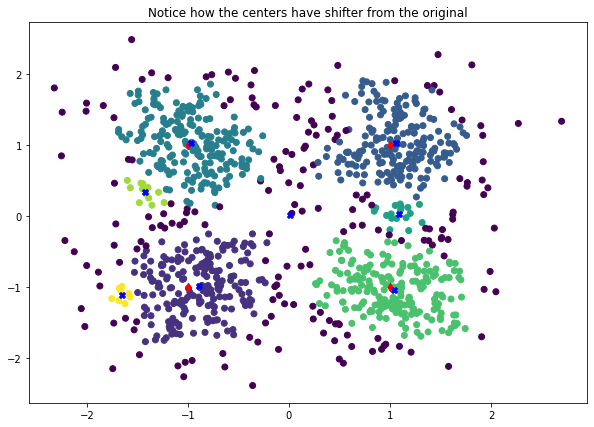

In [199]:
plt.title("Notice how the centers have shifter from the original")
plt.scatter(df.loc[:,0],df.loc[:,1],c=df.dbscan)
plt.scatter(centers[:,0],centers[:,1], color="red",marker="d")
plt.scatter(db_centroids.loc[:,0],db_centroids.loc[:,1], color="blue",marker="X")

## AFFINITY PROPAGATION

In [260]:
af = AffinityPropagation(random_state = 15,damping=.6).fit(x)
df["affinity"] = af.labels_
affinity_centroids = af.cluster_centers_
cluster_centers_indices = af.cluster_centers_indices_
n_clusters = len(affinity_centroids)
affinity_centroids

array([[-1.0434594 , -1.37717259],
       [ 1.31752232, -0.08923302],
       [-1.47557884,  0.77489825],
       [ 1.4129991 , -1.46116456],
       [ 0.80787115, -0.54624499],
       [ 0.89084058, -1.13404572],
       [-0.39895142,  0.79306541],
       [-1.48459542,  1.61210854],
       [-1.24021288,  0.0341415 ],
       [ 1.65919749,  0.9425682 ],
       [-1.02734962,  1.18418961],
       [ 1.16408243,  0.77367153],
       [ 0.57791081, -1.67461661],
       [ 0.51276775,  0.50970743],
       [ 1.07107028,  1.59398407],
       [-0.91475343,  0.66814179],
       [-1.61823122, -1.43742552],
       [-0.86150598, -0.67011695],
       [ 1.51044767, -0.8922688 ],
       [-0.6543724 , -1.93407294],
       [-1.52978933, -0.79083835],
       [-0.23208025, -0.62630698],
       [ 0.50017774,  1.04459135],
       [-0.58027882,  1.64069237],
       [-0.63197164, -1.13927906]])

### LETS SEE IF THERE IS ANY MOVEMENT FROM ORIGINAL BLOB TO OTHER CLUSTERS

- Can you guess what will happen to movement if variance go up or down
- With high variance it looks like most will go to noise

In [261]:
pd.concat([df.labels.value_counts(),df.affinity.value_counts()], axis=1)

,labels,affinity
1,250.0,34
0,250.0,45
3,250.0,40
2,250.0,31
5,NaN,74
11,NaN,69
10,NaN,61
14,NaN,59
24,NaN,53
17,NaN,50


### Affinity Metrics

In [262]:
clustering_metrics(labels_true,af.labels_, n_clusters=n_clusters, n_noise=0)

Estimated number of clusters: 25
Estimated number of noise points: 0
Homogeneity: 0.904
Completeness: 0.397
V-measure: 0.552
Adjusted Rand Index: 0.228
Adjusted Mutual Information: 0.545
Silhouette Coefficient: 0.311


### Affinity Plot

- Notice how the centers have shifted.
- There will be less shift in center if data has less variance

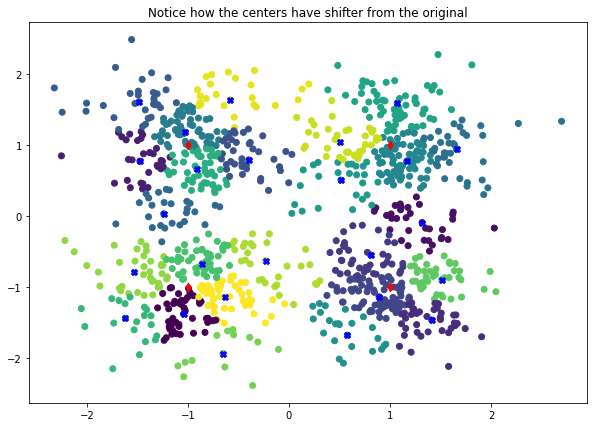

In [263]:
plt.title("Notice how the centers have shifter from the original")
plt.scatter(df.loc[:,0],df.loc[:,1],c=df.affinity)
plt.scatter(centers[:,0],centers[:,1], color="red",marker="d")
plt.scatter(affinity_centroids[:,0],affinity_centroids[:,1], color="blue",marker="X")

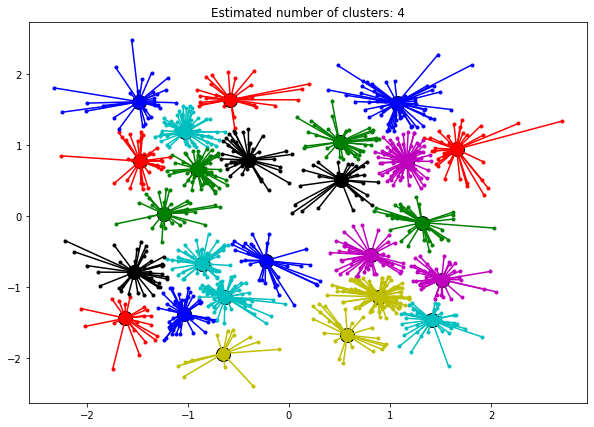

In [264]:
plt.close("all")
plt.clf()

colors = cycle("bgrcmykbgrcmykbgrcmykbgrcmyk")
for k, col in zip(range(n_clusters), colors):
    class_members = af.labels_ == k
    cluster_center = x[cluster_centers_indices[k]]
    plt.plot(x[class_members, 0], x[class_members, 1], col + ".")
    plt.plot(
        cluster_center[0],
        cluster_center[1],
        "o",
        markerfacecolor=col,
        markeredgecolor="k",
        markersize=14,
    )
    for y in x[class_members]:
        plt.plot([cluster_center[0], y[0]], [cluster_center[1], y[1]], col)

plt.title("Estimated number of clusters: %d" % n_clusters_)
plt.show()